Using device: cuda


C:\Users\arman\AppData\Local\Temp\ipykernel_37176\3744332510.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='quality_grade', order=['Low', 'Medium', 'High', 'Premium'], ax=axes[0], palette='viridis')
C:\Users\arman\AppData\Local\Temp\ipykernel_37176\3744332510.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='quality_grade', y='thread_count', order=['Low', 'Medium', 'High', 'Premium'], ax=axes[1], palette='viridis')


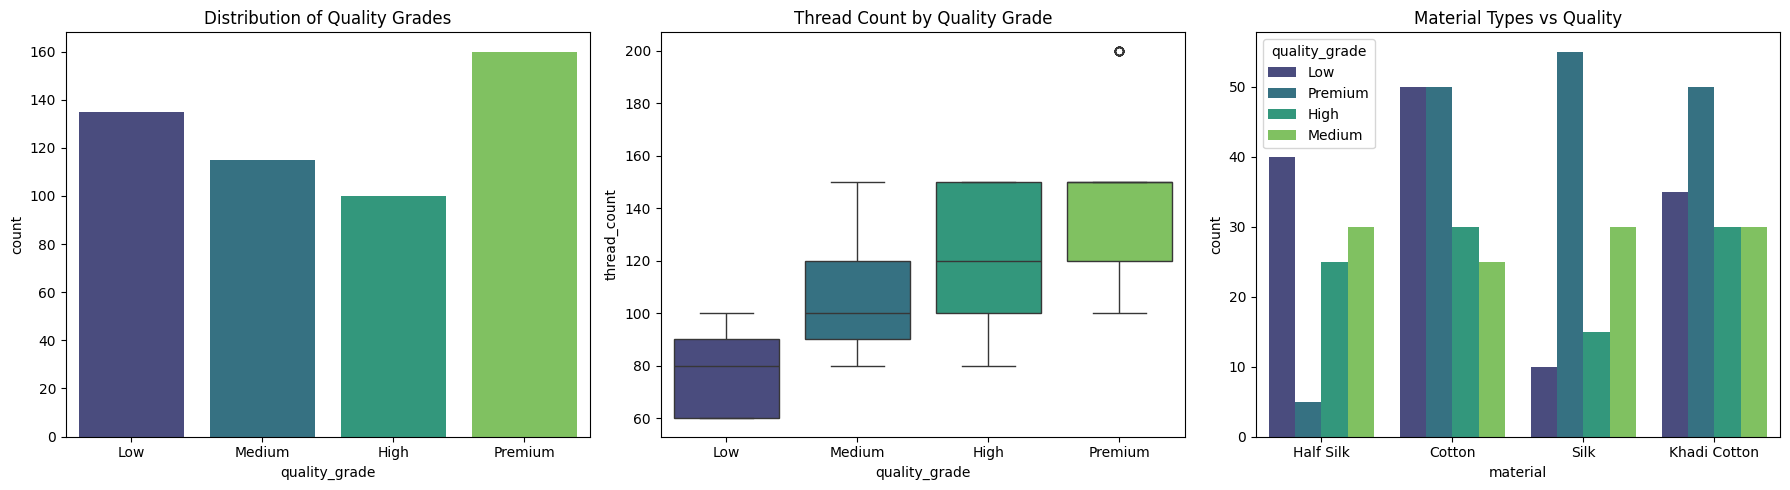


--- Visualizing Multimodal Data Mapping ---


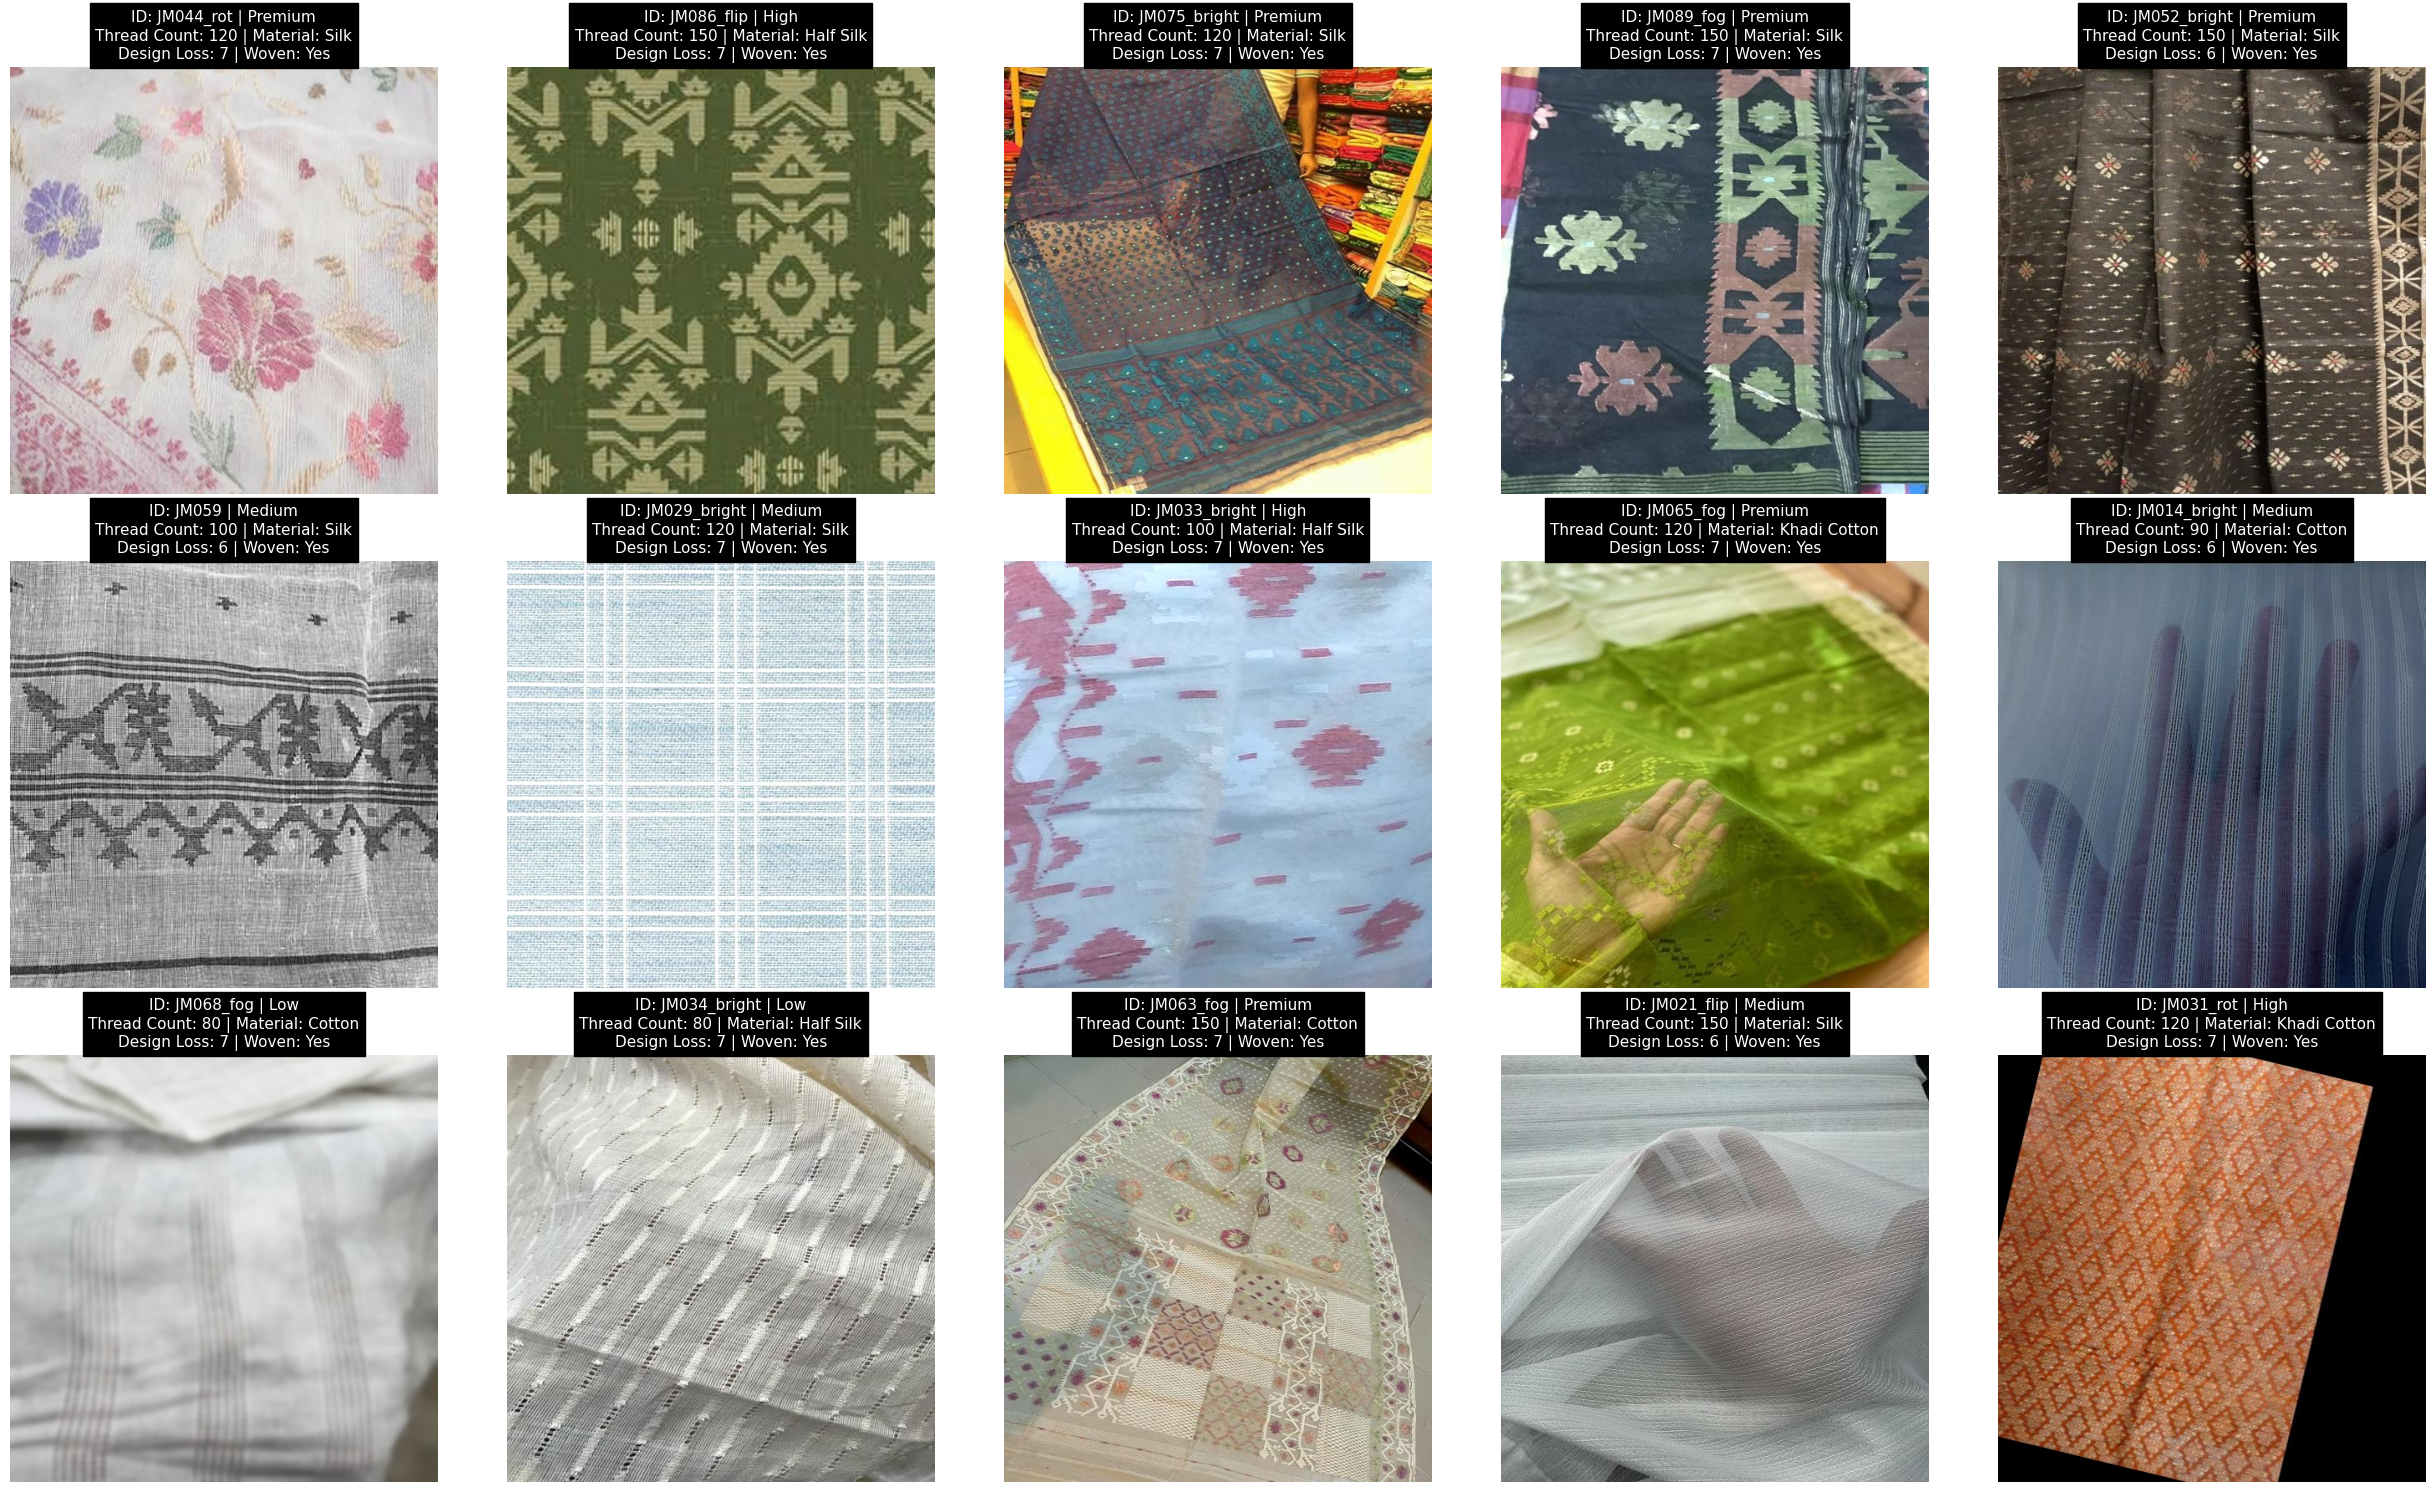

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Load the Tabular Data
excel_filename = 'Jamdani_Samples_Augmented.xlsx' # Ensure this matches your uploaded file name
df = pd.read_excel(excel_filename)

# 2. Exploratory Data Visualization (Charts)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))



sns.countplot(data=df, x='quality_grade', order=['Low', 'Medium', 'High', 'Premium'], ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Quality Grades')

sns.boxplot(data=df, x='quality_grade', y='thread_count', order=['Low', 'Medium', 'High', 'Premium'], ax=axes[1], palette='viridis')
axes[1].set_title('Thread Count by Quality Grade')

sns.countplot(data=df, x='material', hue='quality_grade', ax=axes[2], palette='viridis')
axes[2].set_title('Material Types vs Quality')

plt.tight_layout()
plt.show()


import math

# 3. Visualize Sample Images with their Mapped Features
print("\n--- Visualizing Multimodal Data Mapping ---")
image_folder = './Images' # Ensure your images are inside this folder

# Sample 15 random rows to visualize in a matrix
num_samples = 15
sample_df = df.sample(n=num_samples)

# Define the matrix layout (e.g., 5 columns)
cols = 5
rows = math.ceil(num_samples / cols)

# Adjust figsize so the matrix is wide and tall enough to read the text
# Width=25, Height=15 provides a good balance for a 5-column grid
plt.figure(figsize=(25, 15))

for i, (index, row) in enumerate(sample_df.iterrows()):
    img_name = row['image_name']
    img_path = os.path.join(image_folder, img_name)

    # Subplot takes (rows, columns, current_index)
    plt.subplot(rows, cols, i + 1)

    # Check if the image actually exists in the folder before trying to draw it
    if os.path.exists(img_path):
        img = Image.open(img_path).convert('RGB')
        plt.imshow(img)

        # Map the tabular features to the image title
        feature_text = (
            f"ID: {row['image_id']} | {row['quality_grade']}\n"
            f"Thread Count: {row['thread_count']} | Material: {row['material']}\n"
            f"Design Loss: {row['design_loss']} | Woven: {row['handwoven']}"
        )

        # Font size increased slightly to remain readable in the larger grid
        plt.title(feature_text, fontsize=11, loc='center', backgroundcolor='black', color='white')
        plt.axis('off')
    else:
        # Fallback if the image is missing from the folder
        plt.text(0.5, 0.5, f"Image Not Found:\n{img_name}",
                 ha='center', va='center', fontsize=12, color='red')
        plt.axis('off')

# tight_layout ensures the titles and images don't overlap in the matrix
plt.tight_layout()
plt.show()

In [2]:
missing = [f for f in df['image_name'] if not os.path.exists(os.path.join(image_folder, f))]
print(f"{len(missing)} / {len(df)} files missing")
print(missing[:20])

0 / 510 files missing
[]


--- Advanced Statistical Visualizations for Report ---


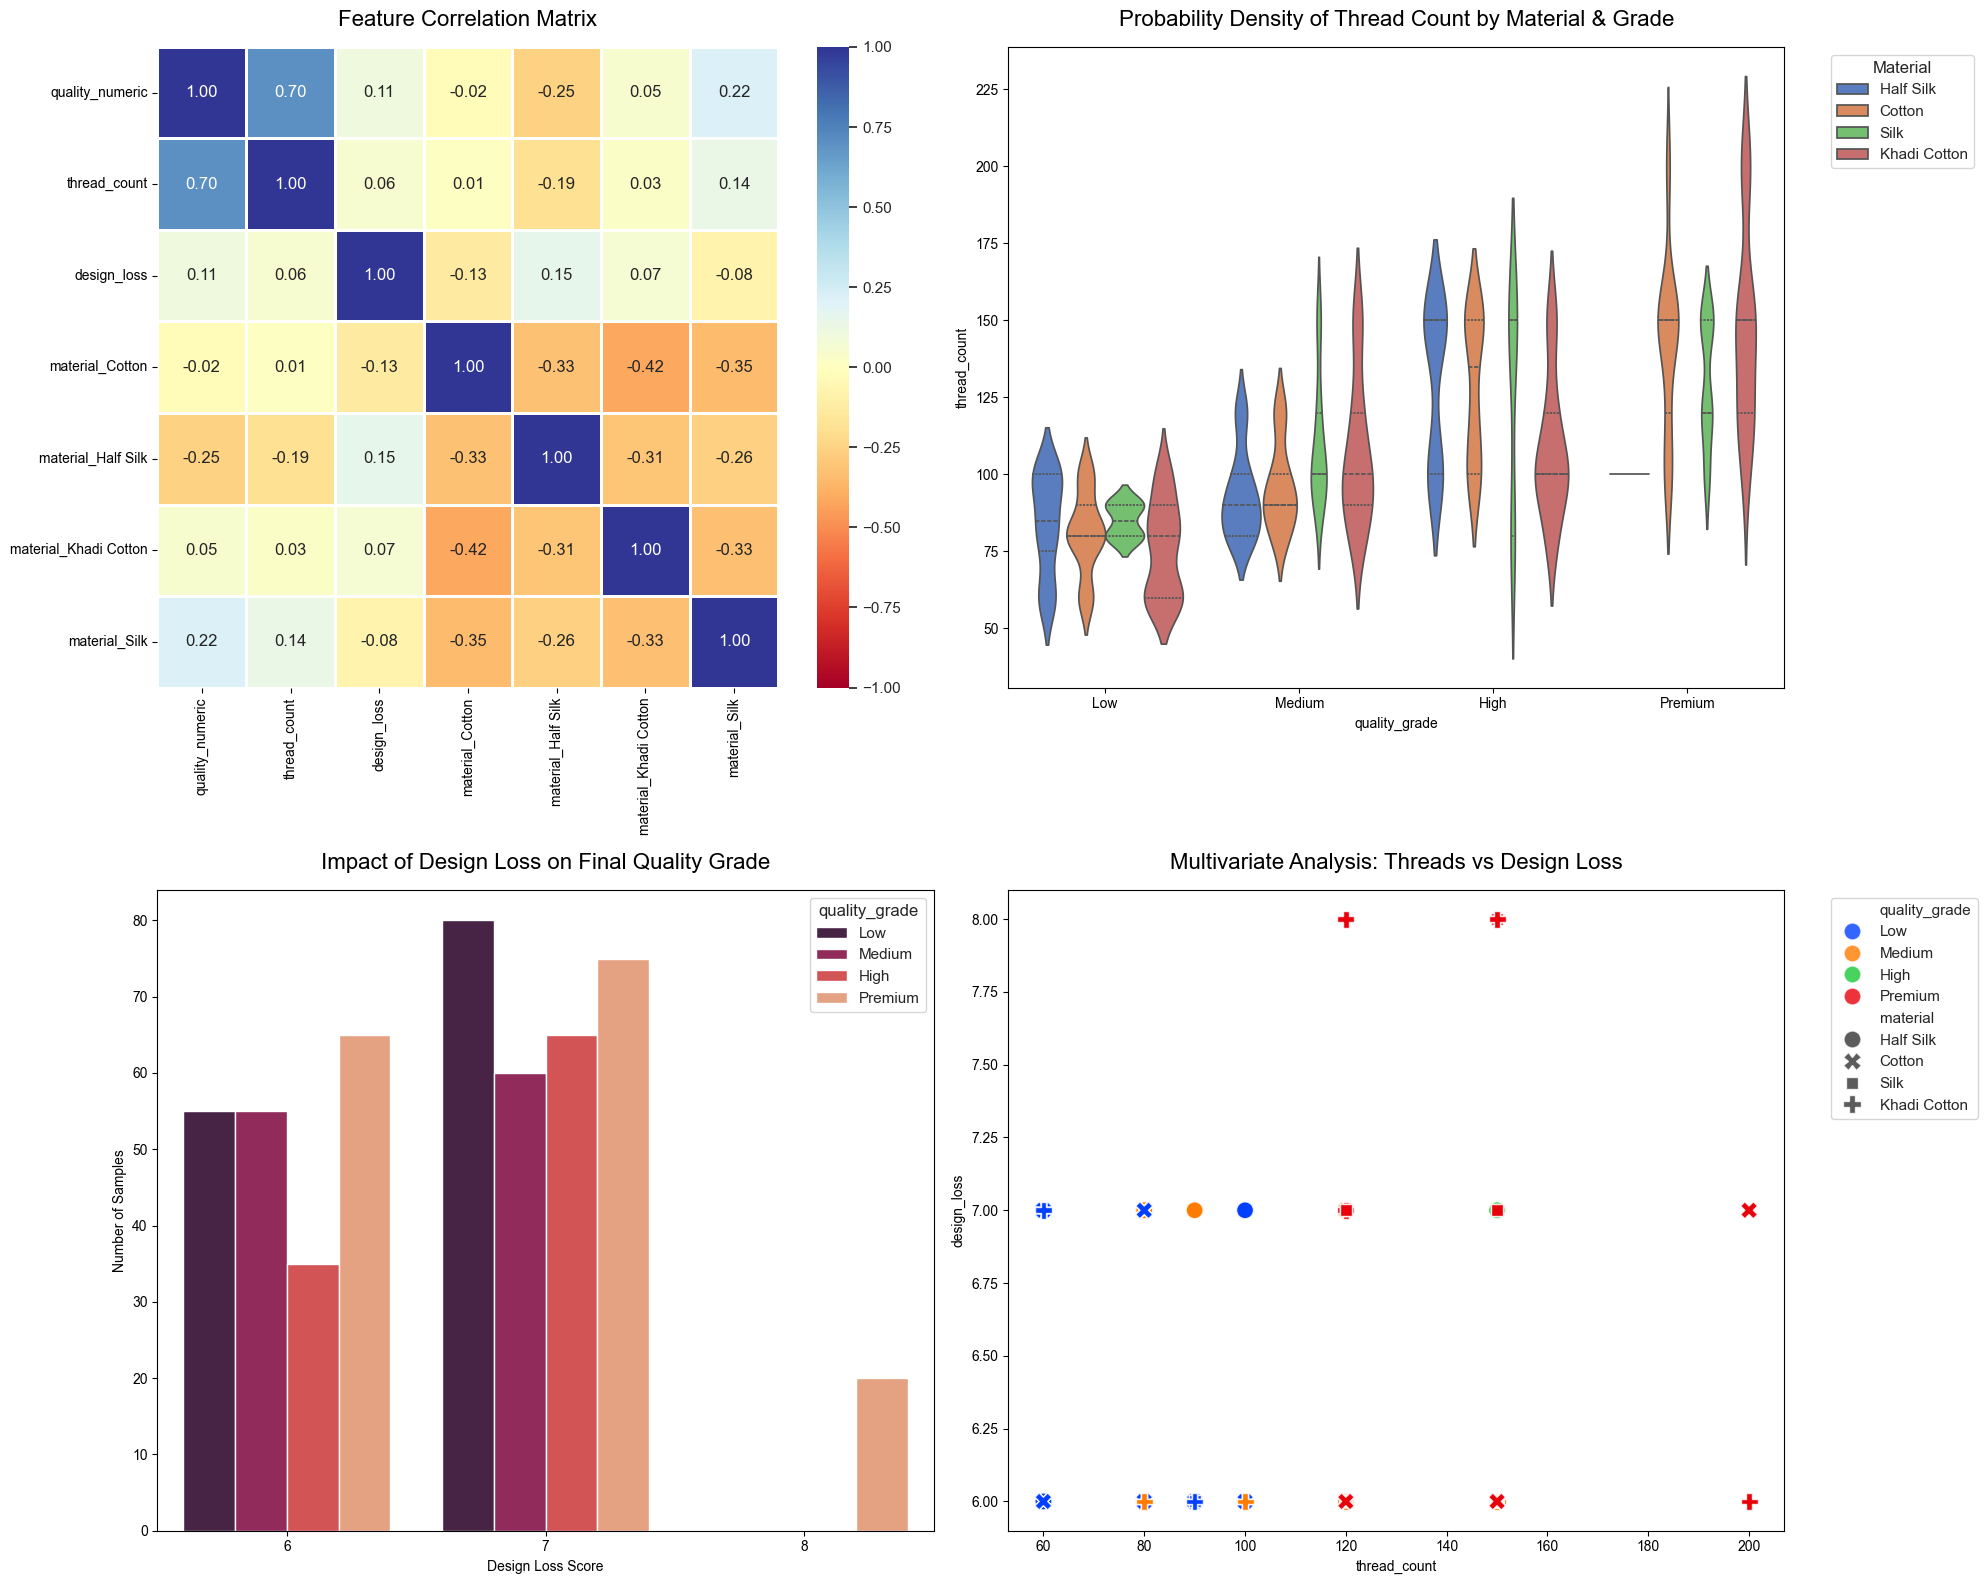

In [3]:

print("--- Advanced Statistical Visualizations for Report ---")

# Create a 2x2 grid for advanced plots
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# Plot 1: Feature Correlation Heatmap
# ---------------------------------------------------------
# We map ordinal quality to numbers so we can calculate mathematical correlation
grade_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Premium': 3}
df_corr = df.copy()
df_corr['quality_numeric'] = df_corr['quality_grade'].map(grade_map)

# One-hot encode the materials to see how specific fabrics correlate
df_corr = pd.get_dummies(df_corr, columns=['material'])
corr_columns = ['quality_numeric', 'thread_count', 'design_loss'] + [c for c in df_corr.columns if 'material_' in c]

# Compute and plot the correlation matrix
corr_matrix = df_corr[corr_columns].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu', fmt=".2f", linewidths=1, ax=axes[0, 0], vmin=-1, vmax=1)
axes[0, 0].set_title('Feature Correlation Matrix', fontsize=16, pad=15)

# ---------------------------------------------------------
# Plot 2: Violin Plot (Distribution Density)
# ---------------------------------------------------------
# Violin plots are great for academic papers. They show both the boxplot and the exact probability density.
sns.violinplot(data=df, x='quality_grade', y='thread_count', hue='material',
               order=['Low', 'Medium', 'High', 'Premium'],
               inner="quartile", palette='muted', ax=axes[0, 1])
axes[0, 1].set_title('Probability Density of Thread Count by Material & Grade', fontsize=16, pad=15)
axes[0, 1].legend(title='Material', bbox_to_anchor=(1.05, 1), loc='upper left')

# ---------------------------------------------------------
# Plot 3: Impact of Design Loss on Quality
# ---------------------------------------------------------
# Shows if higher design loss forces a saree into a lower grade category
sns.countplot(data=df, x='design_loss', hue='quality_grade',
              hue_order=['Low', 'Medium', 'High', 'Premium'],
              palette='rocket', ax=axes[1, 0])
axes[1, 0].set_title('Impact of Design Loss on Final Quality Grade', fontsize=16, pad=15)
axes[1, 0].set_xlabel('Design Loss Score')
axes[1, 0].set_ylabel('Number of Samples')

# ---------------------------------------------------------
# Plot 4: Multivariate Scatter Plot
# ---------------------------------------------------------
# Combines 4 dimensions of data: X (Thread Count), Y (Design Loss), Color (Grade), Shape (Material)
sns.scatterplot(data=df, x='thread_count', y='design_loss', hue='quality_grade',
                style='material', s=150, alpha=0.8,
                hue_order=['Low', 'Medium', 'High', 'Premium'],
                palette='bright', ax=axes[1, 1])
axes[1, 1].set_title('Multivariate Analysis: Threads vs Design Loss', fontsize=16, pad=15)
axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [4]:
# 1. Encode Target Labels (Low, Medium, High, Premium -> 0, 1, 2, 3)
label_encoder = LabelEncoder()
df['target'] = label_encoder.fit_transform(df['quality_grade'])

# 2. Encode Categorical Features & Scale Numerical Features
df = pd.get_dummies(df, columns=['material'], drop_first=False)
feature_cols = ['thread_count', 'design_loss'] + [col for col in df.columns if col.startswith('material_')]

scaler = StandardScaler()
df[['thread_count', 'design_loss']] = scaler.fit_transform(df[['thread_count', 'design_loss']])

# 3. Train-Test Split (80% Train, 20% Test)
# IMPORTANT: since the data is augmented (_bright/_flip/_fog/_rot copies of the
# same original photo), we must split by the ORIGINAL sample, not by row.
# Otherwise near-duplicate images of the same fabric can end up in both train
# and test, which leaks information and inflates test accuracy artificially.
df['base_id'] = df['image_id'].str.replace(r'_(bright|flip|fog|rot)$', '', regex=True)

unique_samples = df.drop_duplicates(subset='base_id')[['base_id', 'target']]
train_ids, test_ids = train_test_split(
    unique_samples['base_id'],
    test_size=0.2,
    random_state=42,
    stratify=unique_samples['target']
)

train_df = df[df['base_id'].isin(train_ids)].reset_index(drop=True)
test_df = df[df['base_id'].isin(test_ids)].reset_index(drop=True)

# 4. Define PyTorch Image Transformations
# MobileNetV2 expects images resized to 224x224 and normalized with specific mean/std
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 5. Build Custom PyTorch Dataset
class JamdaniMultimodalDataset(Dataset):
    def __init__(self, dataframe, img_folder, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_folder = img_folder
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Image
        img_name = self.dataframe.loc[idx, 'image_name']
        img_path = os.path.join(self.img_folder, img_name)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        # Tabular data
        tabular_data = self.dataframe.loc[idx, feature_cols].values.astype(np.float32)
        tabular_tensor = torch.tensor(tabular_data)

        # Label
        label = self.dataframe.loc[idx, 'target']
        label_tensor = torch.tensor(label, dtype=torch.long)

        return image, tabular_tensor, label_tensor

# 6. Create DataLoaders (Batches the data automatically)
train_dataset = JamdaniMultimodalDataset(train_df, 'Images', transform=image_transforms)
test_dataset = JamdaniMultimodalDataset(test_df, 'Images', transform=image_transforms)

train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)

print(f"Tabular features dimension: {len(feature_cols)}")
feature_cols

Tabular features dimension: 6


['thread_count',
 'design_loss',
 'material_Cotton',
 'material_Half Silk',
 'material_Khadi Cotton',
 'material_Silk']

In [5]:
class MultimodalLateFusion(nn.Module):
    def __init__(self, tabular_dim, num_classes=4):
        super(MultimodalLateFusion, self).__init__()

        # --- Branch 1: Image pipeline (feature extractor + its OWN classifier) ---
        mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        self.image_features = mobilenet.features

        for param in self.image_features.parameters():
            param.requires_grad = False

        self.image_pool_and_fc = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(1280, 128),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        # Independent image classifier -> its own logits
        self.image_classifier = nn.Linear(128, num_classes)

        # --- Branch 2: Tabular pipeline (feature extractor + its OWN classifier) ---
        self.tabular_model = nn.Sequential(
            nn.Linear(tabular_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        # Independent tabular classifier -> its own logits
        self.tabular_classifier = nn.Linear(64, num_classes)

        # Learnable fusion weight: how much to trust image vs tabular decision
        # (init 0.5/0.5; sigmoid keeps it bounded 0-1 during training)
        self.fusion_weight_raw = nn.Parameter(torch.tensor(0.0))

    def forward(self, image_x, tabular_x):
        # Image branch -> independent prediction
        img_feat = self.image_features(image_x)
        img_feat = self.image_pool_and_fc(img_feat)
        img_logits = self.image_classifier(img_feat)

        # Tabular branch -> independent prediction
        tab_feat = self.tabular_model(tabular_x)
        tab_logits = self.tabular_classifier(tab_feat)

        # --- Decision-level (late) fusion: combine the two predictions ---
        w = torch.sigmoid(self.fusion_weight_raw)  # learnable weight in [0,1]
        output = w * img_logits + (1 - w) * tab_logits
        return output

# Instantiate the model and move it to the GPU
tabular_input_dim = len(feature_cols)
model = MultimodalLateFusion(tabular_dim=tabular_input_dim).to(device)
print(tabular_input_dim)

print(model)


6
MultimodalLateFusion(
  (image_features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): Bat

Starting training...
Epoch 1/30 | Train Loss: 1.1675 Acc: 0.5062 | Val Loss: 1.0625 Acc: 0.7048
Epoch 2/30 | Train Loss: 0.6968 Acc: 0.8025 | Val Loss: 0.9635 Acc: 0.5238
Epoch 3/30 | Train Loss: 0.5009 Acc: 0.8494 | Val Loss: 0.8884 Acc: 0.6190
Epoch 4/30 | Train Loss: 0.3322 Acc: 0.9136 | Val Loss: 0.8469 Acc: 0.6857
Epoch 5/30 | Train Loss: 0.3028 Acc: 0.9136 | Val Loss: 0.9864 Acc: 0.6857
Epoch 6/30 | Train Loss: 0.2109 Acc: 0.9432 | Val Loss: 0.8781 Acc: 0.5429
Epoch 7/30 | Train Loss: 0.1755 Acc: 0.9556 | Val Loss: 1.0739 Acc: 0.6381
Epoch 8/30 | Train Loss: 0.1164 Acc: 0.9802 | Val Loss: 0.9816 Acc: 0.6286
Epoch 9/30 | Train Loss: 0.1137 Acc: 0.9728 | Val Loss: 1.0373 Acc: 0.5905
Epoch 10/30 | Train Loss: 0.1184 Acc: 0.9605 | Val Loss: 1.0007 Acc: 0.5810
Epoch 11/30 | Train Loss: 0.0688 Acc: 0.9901 | Val Loss: 1.0205 Acc: 0.5429
Epoch 12/30 | Train Loss: 0.0774 Acc: 0.9877 | Val Loss: 1.0894 Acc: 0.6000
Epoch 13/30 | Train Loss: 0.0775 Acc: 0.9802 | Val Loss: 0.9252 Acc: 0.6667


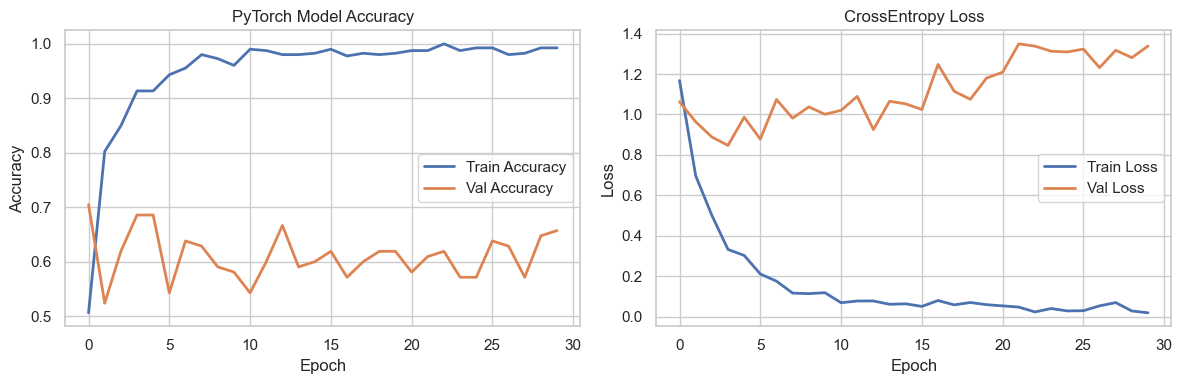

In [6]:
# Hyperparameters
epochs = 30
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Tracking history for plotting
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Starting training...")

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train() # Set model to training mode
    running_loss, running_corrects, total_samples = 0.0, 0, 0

    for images, tabular, labels in train_loader:
        # Move data to GPU
        images, tabular, labels = images.to(device), tabular.to(device), labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images, tabular)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels.data).item()
        total_samples += images.size(0)

    epoch_train_loss = running_loss / total_samples
    epoch_train_acc = running_corrects / total_samples

    # --- VALIDATION PHASE ---
    model.eval() # Set model to evaluation mode (disables dropout)
    val_loss, val_corrects, val_samples = 0.0, 0, 0

    with torch.no_grad(): # Disable gradient calculation for speed
        for images, tabular, labels in test_loader:
            images, tabular, labels = images.to(device), tabular.to(device), labels.to(device)

            outputs = model(images, tabular)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * images.size(0)
            val_corrects += torch.sum(preds == labels.data).item()
            val_samples += images.size(0)

    epoch_val_loss = val_loss / val_samples
    epoch_val_acc = val_corrects / val_samples

    # Save metrics
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")

# Plotting the Results
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy', lw=2)
plt.plot(history['val_acc'], label='Val Accuracy', lw=2)
plt.title('PyTorch Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', lw=2)
plt.plot(history['val_loss'], label='Val Loss', lw=2)
plt.title('CrossEntropy Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [7]:
# Install Optuna silently
!pip install -q optuna
import optuna


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\arman\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
train_dataset = JamdaniMultimodalDataset(train_df, 'Images', transform=image_transforms)
val_dataset = JamdaniMultimodalDataset(test_df, 'Images', transform=image_transforms)

train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import optuna


NUM_CLASSES = 4
TABULAR_DIM = len(feature_cols)# <-- Replace with your actual number of tabular columns
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. Define the Multi-Modal Architecture ---
class MultiModalNet(nn.Module):
    def __init__(self, base_image_model, tabular_dim, num_classes, dropout_rate=0.2):
        super(MultiModalNet, self).__init__()

        self.image_backbone = base_image_model.features

        self.image_pool_and_fc = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(1280, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        self.image_classifier = nn.Linear(128, num_classes)

        self.tabular_model = nn.Sequential(
            nn.Linear(tabular_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        self.tabular_classifier = nn.Linear(64, num_classes)

        self.fusion_weight_raw = nn.Parameter(torch.tensor(0.0))

    def forward(self, image, tabular):
        img_features = self.image_backbone(image)
        img_out = self.image_pool_and_fc(img_features)
        img_logits = self.image_classifier(img_out)

        tab_out = self.tabular_model(tabular)
        tab_logits = self.tabular_classifier(tab_out)

        w = torch.sigmoid(self.fusion_weight_raw)
        return w * img_logits + (1 - w) * tab_logits

# --- 2. Initialize Model Function ---
def get_multimodal_model(dropout_rate=0.2):
    """Initializes MobileNetV2 and wraps it in the MultiModalNet."""
    base_model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

    # Freeze image feature extractor layers for faster hyperparameter search
    for param in base_model.features.parameters():
        param.requires_grad = False

    # Instantiate our custom class
    model = MultiModalNet(
        base_image_model=base_model,
        tabular_dim=TABULAR_DIM,
        num_classes=NUM_CLASSES,
        dropout_rate=dropout_rate
    )
    return model


# --- 3. Optuna Objective Function ---
def objective(trial):
    # Suggest Hyperparameters
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["AdamW", "Adam", "SGD"])

    model = get_multimodal_model(dropout_rate=dropout).to(device)
    modelcheck=model;
    criterion = nn.CrossEntropyLoss()


    # Get only the un-frozen parameters (the newly added linear and fusion layers)
    trainable_params = [p for p in model.parameters() if p.requires_grad]

    if optimizer_name == "SGD":
        optimizer = optim.SGD(trainable_params, lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        optimizer = getattr(optim, optimizer_name)(trainable_params, lr=lr, weight_decay=weight_decay)

    epochs_per_trial = 5
    for epoch in range(epochs_per_trial):
        model.train()

        # --- Training Loop ---
        for batch in train_loader:
            # Safely unpack Image, Tabular, and Labels
            if isinstance(batch, dict):
                images = batch['image']
                tabular = batch['tabular'] # <-- Ensure this matches your dataset keys
                labels = batch['label']
            else:
                # Assumes dataset returns: (image, tabular, label)
                images, tabular, labels = batch[0], batch[1], batch[2]

            images = images.to(device)
            tabular = tabular.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            # Forward pass requires both inputs
            outputs = model(images, tabular)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # --- Validation Loop ---
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for batch in val_loader:
                if isinstance(batch, dict):
                    images = batch['image']
                    tabular = batch['tabular']
                    labels = batch['label']
                else:
                    images, tabular, labels = batch[0], batch[1], batch[2]

                images = images.to(device)
                tabular = tabular.to(device)
                labels = labels.to(device)

                # Forward pass requires both inputs
                outputs = model(images, tabular)

                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_acc = correct / total

        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return val_acc

In [10]:
# Create study and run optimization
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=15)

print("\n--- Optuna Study Summary ---")
print(f"Best Validation Accuracy: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-09-25 22:22:48,745] A new study created in memory with name: no-name-a00683c3-fd2d-4f31-9ae7-779d72ba77b3
[I 2026-09-25 22:23:06,347] Trial 0 finished with value: 0.3619047619047619 and parameters: {'lr': 3.7951928355869266e-05, 'dropout': 0.16957596001367664, 'weight_decay': 7.04718886490567e-06, 'optimizer': 'SGD'}. Best is trial 0 with value: 0.3619047619047619.
[I 2026-09-25 22:23:23,689] Trial 1 finished with value: 0.5523809523809524 and parameters: {'lr': 0.0009467370643748576, 'dropout': 0.1735865497180872, 'weight_decay': 4.0209827582190915e-06, 'optimizer': 'AdamW'}. Best is trial 1 with value: 0.5523809523809524.
[I 2026-09-25 22:23:40,455] Trial 2 finished with value: 0.6190476190476191 and parameters: {'lr': 0.008333152486042165, 'dropout': 0.17901849325832467, 'weight_decay': 2.2546636163682778e-05, 'optimizer': 'AdamW'}. Best is trial 2 with value: 0.6190476190476191.
[I 2026-09-25 22:23:58,091] Trial 3 finished with value: 0.6190476190476191 and parameters: {'lr


--- Optuna Study Summary ---
Best Validation Accuracy: 0.6190
Best Hyperparameters:
  lr: 0.008333152486042165
  dropout: 0.17901849325832467
  weight_decay: 2.2546636163682778e-05
  optimizer: AdamW


In [11]:
import copy
print("\n--- Training Final Model ---")
best_params = study.best_params

#print(best_params["batch_size"])

# Use a default batch size if not tuned by Optuna
batch_size = best_params.get("batch_size", 32)

# If train_dataset exists, rebuild loaders; otherwise use existing loaders
if "train_dataset" in globals() and "val_dataset" in globals():
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

final_model = get_multimodal_model(dropout_rate=best_params["dropout"]).to(device)

# Unfreeze top layers of MobileNet for fine-tuning
# The corrected line
for param in final_model.image_backbone[-3:].parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()

if best_params["optimizer"] == "SGD":
    optimizer = optim.SGD(
        final_model.parameters(),
        lr=best_params["lr"],
        momentum=0.9,
        weight_decay=best_params["weight_decay"]
    )
else:
    optimizer = getattr(optim, best_params["optimizer"])(
        final_model.parameters(),
        lr=best_params["lr"],
        weight_decay=best_params["weight_decay"]
    )

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

num_epochs = 30
best_accuracy = 0.0
best_model_weights = copy.deepcopy(final_model.state_dict())

for epoch in range(num_epochs):
    final_model.train()
    running_loss, correct, total = 0.0, 0, 0

    # Robust unpacking for multimodal or tuple batches
    for batch in train_loader:
        if isinstance(batch, dict):
            images, tabular, labels = batch['image'], batch['tabular'], batch['label']
        else:
            images, tabular, labels = batch[0], batch[1], batch[2]

        images, tabular, labels = images.to(device), tabular.to(device), labels.to(device)

        optimizer.zero_grad()
        # The corrected line:
        outputs = final_model(images, tabular)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    scheduler.step()
    train_loss = running_loss / total
    train_acc = correct / total

    # Validation
    final_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for batch in val_loader:
            if isinstance(batch, dict):
                images, tabular, labels = batch['image'], batch['tabular'], batch['label']
            else:
                images, tabular, labels = batch[0], batch[1], batch[2]

            images, tabular, labels = images.to(device), tabular.to(device), labels.to(device)
            # The corrected line:
            outputs = final_model(images, tabular)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1:02d}/{num_epochs:02d} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    if val_acc > best_accuracy:
        best_accuracy = val_acc
        best_model_weights = copy.deepcopy(final_model.state_dict())

# Save best model checkpoint
final_model.load_state_dict(best_model_weights)
torch.save(final_model.state_dict(), 'best_mobilenet_jamdani.pth')
print(f"\nFinal Best Validation Accuracy: {best_accuracy:.4f}")
print("Saved model checkpoint as 'best_mobilenet_jamdani.pth' in your Drive!")


--- Training Final Model ---
Epoch 01/30 | Train Loss: 0.6852, Acc: 0.6914 | Val Loss: 12.9081, Acc: 0.5048
Epoch 02/30 | Train Loss: 0.4373, Acc: 0.9037 | Val Loss: 13.2756, Acc: 0.5048
Epoch 03/30 | Train Loss: 0.3330, Acc: 0.9136 | Val Loss: 3.2601, Acc: 0.6000
Epoch 04/30 | Train Loss: 0.1340, Acc: 0.9605 | Val Loss: 3.7147, Acc: 0.4476
Epoch 05/30 | Train Loss: 0.0610, Acc: 0.9852 | Val Loss: 2.6549, Acc: 0.5810
Epoch 06/30 | Train Loss: 0.0468, Acc: 0.9852 | Val Loss: 1.9847, Acc: 0.6286
Epoch 07/30 | Train Loss: 0.0770, Acc: 0.9728 | Val Loss: 1.8452, Acc: 0.6762
Epoch 08/30 | Train Loss: 0.0436, Acc: 0.9877 | Val Loss: 2.1852, Acc: 0.6095
Epoch 09/30 | Train Loss: 0.0172, Acc: 0.9951 | Val Loss: 1.6590, Acc: 0.6762
Epoch 10/30 | Train Loss: 0.0048, Acc: 1.0000 | Val Loss: 1.6631, Acc: 0.6571
Epoch 11/30 | Train Loss: 0.0350, Acc: 0.9951 | Val Loss: 1.6375, Acc: 0.6190
Epoch 12/30 | Train Loss: 0.0327, Acc: 0.9926 | Val Loss: 1.7642, Acc: 0.6476
Epoch 13/30 | Train Loss: 0.0331

In [12]:
print("\n--- Optimized Hyperparameters ---")
for key, value in best_params.items():
    print(f"{key}: {value}")


--- Optimized Hyperparameters ---
lr: 0.008333152486042165
dropout: 0.17901849325832467
weight_decay: 2.2546636163682778e-05
optimizer: AdamW


In [13]:
# ==========================================
# MULTIMODAL ONLY STUDY: JAMDANI FABRIC
# Models: DenseNet, ConvNeXt, Swin, MobileNetV3
# ==========================================
import timm
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, mean_squared_error, precision_recall_fscore_support

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

multimodal_results = []
tabular_dim = len(feature_cols)
NUM_CLASSES = 4 # 0=Low, 1=Medium, 2=High, 3=Premium



Using device: cuda



In [14]:
# ---------------------------------------------------------
# 1. HELPER FUNCTION: DETAILED EPOCH TRACKING (MULTIMODAL ONLY)
# ---------------------------------------------------------
def train_eval_multimodal(model, train_loader, test_loader, model_name, epochs=15):
    print(f"==========================================")
    print(f" TRAINING: {model_name}")
    print(f"==========================================")
    
    # Using Adam optimizer with learning rate 0.001
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_samples = 0
        
        progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False, unit="batch")
        
        for batch in progress:
            # Extract Image, Tabular, and Label from your Jamdani DataLoader
            images = batch[0].to(device)
            tabs = batch[1].to(device)
            labels = batch[2].to(device)
            
            optimizer.zero_grad()
            
            # Forward pass: Multimodal fusion
            outputs = model(images, tabs)
            loss = criterion(outputs, labels)
            
            # Backward pass & Optimize
            loss.backward()
            optimizer.step()
            
            # Track Loss and Train Accuracy dynamically
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * labels.size(0)
            running_corrects += torch.sum(preds == labels.data).item()
            total_samples += labels.size(0)
            
            live_acc = (running_corrects / total_samples) * 100
            progress.set_postfix(Loss=f"{loss.item():.4f}", TrainAcc=f"{live_acc:.2f}%")
            
        epoch_loss = running_loss / total_samples
        epoch_train_acc = (running_corrects / total_samples) * 100
        
        # --- Validation Phase ---
        model.eval()
        val_corrects, val_samples = 0, 0
        with torch.no_grad():
            for batch in test_loader:
                images, tabs, labels = batch[0].to(device), batch[1].to(device), batch[2].to(device)
                
                outputs = model(images, tabs)
                _, preds = torch.max(outputs, 1)
                
                val_corrects += torch.sum(preds == labels.data).item()
                val_samples += labels.size(0)
                
        epoch_val_acc = (val_corrects / val_samples) * 100
        print(f"Epoch {epoch+1}/{epochs} Completed | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}%")

    # --- Metric Extraction ---
    print(f"Extracting Final Metrics for {model_name}...\n")
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            images, tabs, labels = batch[0].to(device), batch[1].to(device), batch[2].to(device)
            
            outputs = model(images, tabs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
    rmse = np.sqrt(mean_squared_error(all_labels, all_preds))
    
    return {'Model': model_name, 'Accuracy': epoch_val_acc/100, 'Precision': p, 'Recall': r, 'F1-Score': f1, 'RMSE': rmse}


In [15]:
class JamdaniMultimodalFusion(nn.Module):
    def __init__(self, tabular_dim, backbone_name, num_classes):
        super(JamdaniMultimodalFusion, self).__init__()
        self.vision_backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0)

        for param in self.vision_backbone.parameters():
            param.requires_grad = False

        dummy_input = torch.randn(1, 3, 224, 224)
        vision_dim = self.vision_backbone(dummy_input).shape[1]

        # Vision branch: feature reducer + its OWN classifier
        self.vision_fc = nn.Sequential(nn.Linear(vision_dim, 128), nn.ReLU())
        self.vision_classifier = nn.Linear(128, num_classes)

        # Tabular branch: feature extractor + its OWN classifier
        self.tabular_model = nn.Sequential(
            nn.Linear(tabular_dim, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU()
        )
        self.tabular_classifier = nn.Linear(64, num_classes)

        # Learnable decision-level fusion weight
        self.fusion_weight_raw = nn.Parameter(torch.tensor(0.0))

    def forward(self, img, tab):
        img_feat = self.vision_fc(self.vision_backbone(img))
        img_logits = self.vision_classifier(img_feat)

        tab_feat = self.tabular_model(tab)
        tab_logits = self.tabular_classifier(tab_feat)

        w = torch.sigmoid(self.fusion_weight_raw)
        return w * img_logits + (1 - w) * tab_logits

In [16]:

# ---------------------------------------------------------
# 3. EXECUTION: TRAIN THE 4 MULTIMODAL MODELS
# ---------------------------------------------------------
# Exact timm registry names for the 4 state-of-the-art backbones
backbones = [
    # --- The Original 4 ---
    'densenet121', 
    'convnext_tiny', 
    'swin_tiny_patch4_window7_224', 
    'mobilenetv3_large_100',
    
    # --- The 4 Academic Standards ---
    'resnet50', 
    'efficientnet_b0', 
    'vit_tiny_patch16_224', 
    
    # --- The 5 New Advanced Models ---
    'seresnet50',             # Squeeze-and-Excitation Network
    'deit_tiny_patch16_224',  # Data-efficient Image Transformer
    'resnet18',               # Lightweight CNN Baseline
    'ghostnet_100',           # Highly efficient "Ghost" feature network
    'regnety_002',            # Neural Architecture Search (AI-designed network)
    'vgg16_bn'
]

for bb in backbones:
    m_model = JamdaniMultimodalFusion(tabular_dim=tabular_dim, backbone_name=bb, num_classes=NUM_CLASSES).to(device)
    res = train_eval_multimodal(m_model, train_loader, test_loader, f"Multimodal Fusion ({bb.upper()})", epochs=15)
    multimodal_results.append(res)


 TRAINING: Multimodal Fusion (DENSENET121)


Epoch 1/15 Completed | Train Loss: 1.1804 | Train Acc: 51.11% | Val Acc: 57.14%


Epoch 2/15 Completed | Train Loss: 0.6344 | Train Acc: 88.15% | Val Acc: 67.62%


Epoch 3/15 Completed | Train Loss: 0.3326 | Train Acc: 95.06% | Val Acc: 56.19%


Epoch 4/15 Completed | Train Loss: 0.1813 | Train Acc: 97.53% | Val Acc: 60.95%


...

Epoch 11/15 Completed | Train Loss: 0.0082 | Train Acc: 100.00% | Val Acc: 49.52%


Epoch 12/15 Completed | Train Loss: 0.0078 | Train Acc: 100.00% | Val Acc: 51.43%


Epoch 13/15 Completed | Train Loss: 0.0054 | Train Acc: 100.00% | Val Acc: 49.52%


Epoch 14/15 Completed | Train Loss: 0.0061 | Train Acc: 100.00% | Val Acc: 49.52%


Epoch 15/15 Completed | Train Loss: 0.0050 | Train Acc: 100.00% | Val Acc: 49.52%
Extracting Final Metrics for Multimodal Fusion (VGG16_BN)...




 JAMDANI FABRIC: MULTIMODAL PERFORMANCE ANALYSIS
                                           Model  Accuracy  Precision  Recall  F1-Score   RMSE
                 Multimodal Fusion (DENSENET121)    0.5714     0.5703  0.5714    0.5654 1.4041
               Multimodal Fusion (CONVNEXT_TINY)    0.5143     0.5422  0.5143    0.5166 1.3663
Multimodal Fusion (SWIN_TINY_PATCH4_WINDOW7_224)    0.4381     0.4378  0.4381    0.4372 1.3732
       Multimodal Fusion (MOBILENETV3_LARGE_100)    0.5238     0.5410  0.5238    0.5254 1.4800
                    Multimodal Fusion (RESNET50)    0.5905     0.6140  0.5905    0.5794 1.1832
             Multimodal Fusion (EFFICIENTNET_B0)    0.4762     0.5010  0.4762    0.4864 1.3093
        Multimodal Fusion (VIT_TINY_PATCH16_224)    0.6476     0.6731  0.6476    0.6564 0.9309
                  Multimodal Fusion (SERESNET50)    0.5524     0.5879  0.5524    0.5622 1.0189
       Multimodal Fusion (DEIT_TINY_PATCH16_224)    0.5333     0.5461  0.5333    0.5354 1.2873


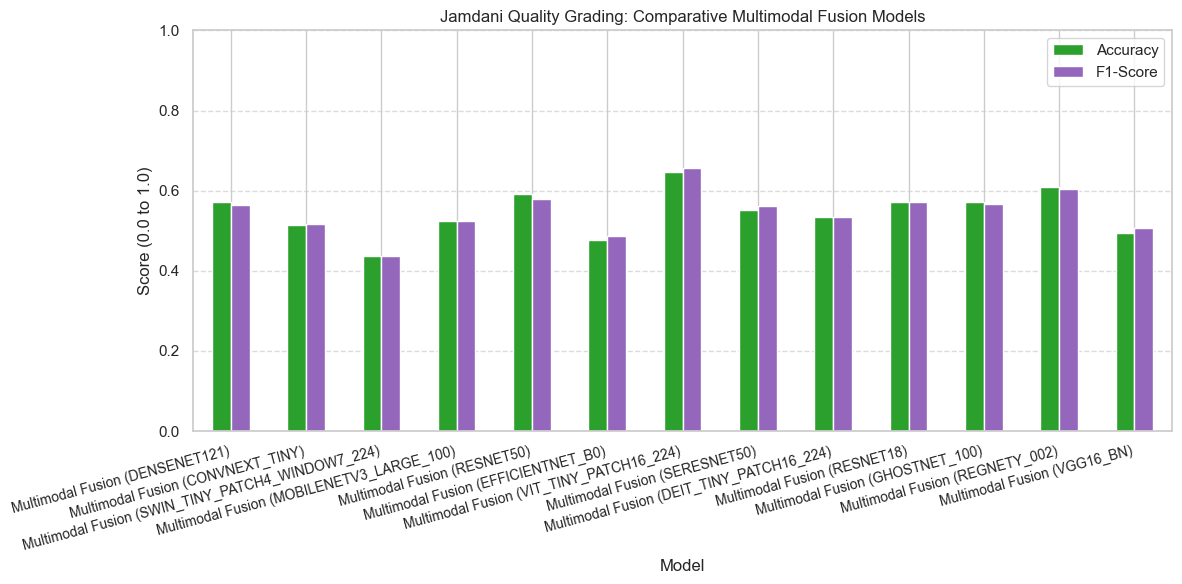

In [17]:

# ---------------------------------------------------------
# 4. FINAL COMPARATIVE VISUALIZATION
# ---------------------------------------------------------
final_df = pd.DataFrame(multimodal_results)

print("\n========================================================")
print(" JAMDANI FABRIC: MULTIMODAL PERFORMANCE ANALYSIS")
print("========================================================")
print(final_df.round(4).to_string(index=False))

# Comparative Bar Chart
final_df.set_index('Model')[['Accuracy', 'F1-Score']].plot(kind='bar', figsize=(12, 6), color=['#2ca02c', '#9467bd'])
plt.title('Jamdani Quality Grading: Comparative Multimodal Fusion Models')
plt.ylabel('Score (0.0 to 1.0)')
plt.ylim(0, 1)
plt.xticks(rotation=15, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

--- Starting 5-Fold Stratified Cross-Validation ---

>> Fold 1/5 Training...
Fold 1 Best Validation Accuracy: 71.43%
*** Fold 1 saved as BEST fold ***

>> Fold 2/5 Training...
Fold 2 Best Validation Accuracy: 65.71%

>> Fold 3/5 Training...
Fold 3 Best Validation Accuracy: 55.00%

>> Fold 4/5 Training...
Fold 4 Best Validation Accuracy: 76.00%
*** Fold 4 saved as BEST fold ***

>> Fold 5/5 Training...
Fold 5 Best Validation Accuracy: 79.00%
*** Fold 5 saved as BEST fold ***

5-Fold CV Final Results:
 - Fold 1: 71.43%
 - Fold 2: 65.71%
 - Fold 3: 55.00%
 - Fold 4: 76.00%
 - Fold 5: 79.00%
Average Accuracy: 69.43% (+/- 8.49%)

Best Fold Information:
Best Fold: 5
Best Fold Accuracy: 79.00%
Best Fold Training Samples: 410
Best Fold Validation Samples: 100


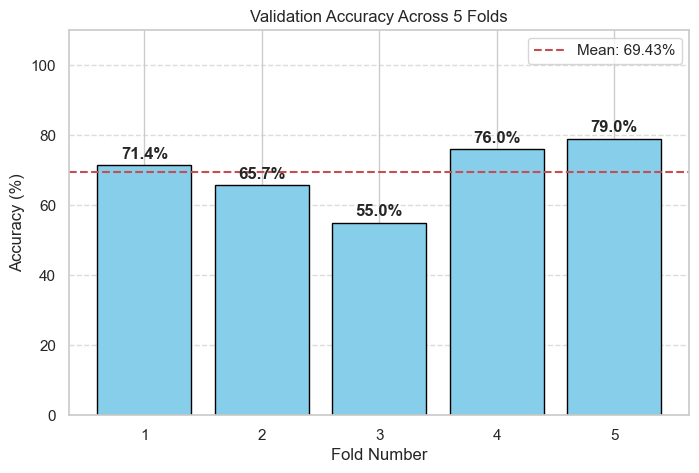

In [18]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
import numpy as np
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

k_folds = 5
epochs_per_fold = 15

skf = StratifiedGroupKFold(n_splits=k_folds, shuffle=True, random_state=42)

fold_results = []
all_train_loss = []
all_val_acc = []

# Store the best fold
best_fold_acc = -1
best_fold_number = None
best_train_loader = None
best_val_loader = None
best_train_df = None
best_val_df = None
best_scaler = None

print(f"--- Starting {k_folds}-Fold Stratified Cross-Validation ---")

for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['target'], groups=df['base_id'])):
    print(f"\n>> Fold {fold + 1}/{k_folds} Training...")

    # Split DataFrame
    train_df = df.iloc[train_idx].copy().reset_index(drop=True)
    val_df = df.iloc[val_idx].copy().reset_index(drop=True)

    # Scale data inside the fold to prevent data leakage
    scaler = StandardScaler()

    train_df[['thread_count', 'design_loss']] = scaler.fit_transform(
        train_df[['thread_count', 'design_loss']]
    )

    val_df[['thread_count', 'design_loss']] = scaler.transform(
        val_df[['thread_count', 'design_loss']]
    )

    # Create datasets
    train_dataset = JamdaniMultimodalDataset(
        train_df, 'Images', transform=image_transforms
    )

    val_dataset = JamdaniMultimodalDataset(
        val_df, 'Images', transform=image_transforms
    )

    # Create DataLoaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=16,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=16,
        shuffle=False
    )

    # Fresh model for each fold
    model = MultimodalLateFusion(
        tabular_dim=len(feature_cols)
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    fold_train_loss_history = []
    fold_val_acc_history = []

    # Training
    for epoch in range(epochs_per_fold):
        model.train()
        running_loss = 0.0

        for images, tabular, labels in train_loader:
            images = images.to(device)
            tabular = tabular.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images, tabular)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        fold_train_loss_history.append(epoch_train_loss)

        # Validation
        model.eval()
        val_corrects = 0
        val_samples = 0

        with torch.no_grad():
            for images, tabular, labels in val_loader:
                images = images.to(device)
                tabular = tabular.to(device)
                labels = labels.to(device)

                outputs = model(images, tabular)
                _, preds = torch.max(outputs, 1)

                val_corrects += torch.sum(preds == labels.data).item()
                val_samples += images.size(0)

        epoch_val_acc = val_corrects / val_samples * 100
        fold_val_acc_history.append(epoch_val_acc)

    # Best accuracy of current fold
    current_fold_best_acc = max(fold_val_acc_history)

    fold_results.append(current_fold_best_acc)
    all_train_loss.append(fold_train_loss_history)
    all_val_acc.append(fold_val_acc_history)

    print(
        f"Fold {fold + 1} Best Validation Accuracy: "
        f"{current_fold_best_acc:.2f}%"
    )

    # Save data from the best-performing fold
    if current_fold_best_acc > best_fold_acc:
        best_fold_acc = current_fold_best_acc
        best_fold_number = fold + 1

        best_train_loader = train_loader
        best_val_loader = val_loader

        best_train_df = train_df.copy()
        best_val_df = val_df.copy()

        best_scaler = copy.deepcopy(scaler)

        print(f"*** Fold {fold + 1} saved as BEST fold ***")


# Final results
print("\n=======================================================")
print(f"{k_folds}-Fold CV Final Results:")

for i, acc in enumerate(fold_results):
    print(f" - Fold {i + 1}: {acc:.2f}%")

mean_accuracy = np.mean(fold_results)
std_accuracy = np.std(fold_results)

print(
    f"Average Accuracy: {mean_accuracy:.2f}% "
    f"(+/- {std_accuracy:.2f}%)"
)

print("=======================================================")

# Best fold information
print("\nBest Fold Information:")
print(f"Best Fold: {best_fold_number}")
print(f"Best Fold Accuracy: {best_fold_acc:.2f}%")
print(f"Best Fold Training Samples: {len(best_train_df)}")
print(f"Best Fold Validation Samples: {len(best_val_df)}")

# Plot results
plt.figure(figsize=(8, 5))

bars = plt.bar(
    range(1, k_folds + 1),
    fold_results,
    color='skyblue',
    edgecolor='black'
)

plt.axhline(
    y=mean_accuracy,
    color='r',
    linestyle='--',
    label=f'Mean: {mean_accuracy:.2f}%'
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 1,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.title('Validation Accuracy Across 5 Folds')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Starting training...
Epoch 1/30 | Train Loss: 0.0353 Acc: 0.9976 | Val Loss: 0.9207 Acc: 0.7700
Epoch 2/30 | Train Loss: 0.0687 Acc: 0.9829 | Val Loss: 1.0213 Acc: 0.6600
Epoch 3/30 | Train Loss: 0.0481 Acc: 0.9878 | Val Loss: 1.0160 Acc: 0.7500
Epoch 4/30 | Train Loss: 0.0314 Acc: 0.9951 | Val Loss: 0.9069 Acc: 0.7800
Epoch 5/30 | Train Loss: 0.0293 Acc: 0.9927 | Val Loss: 0.9593 Acc: 0.6900
Epoch 6/30 | Train Loss: 0.0256 Acc: 0.9951 | Val Loss: 1.0414 Acc: 0.7000
Epoch 7/30 | Train Loss: 0.0223 Acc: 0.9951 | Val Loss: 0.9154 Acc: 0.7700
Epoch 8/30 | Train Loss: 0.0214 Acc: 0.9927 | Val Loss: 1.0915 Acc: 0.6900
Epoch 9/30 | Train Loss: 0.0087 Acc: 1.0000 | Val Loss: 0.9216 Acc: 0.7400
Epoch 10/30 | Train Loss: 0.0248 Acc: 0.9927 | Val Loss: 1.0013 Acc: 0.7600
Epoch 11/30 | Train Loss: 0.0166 Acc: 0.9951 | Val Loss: 0.9496 Acc: 0.7800
Epoch 12/30 | Train Loss: 0.0283 Acc: 0.9951 | Val Loss: 1.1890 Acc: 0.7500
Epoch 13/30 | Train Loss: 0.0308 Acc: 0.9902 | Val Loss: 0.8801 Acc: 0.7700


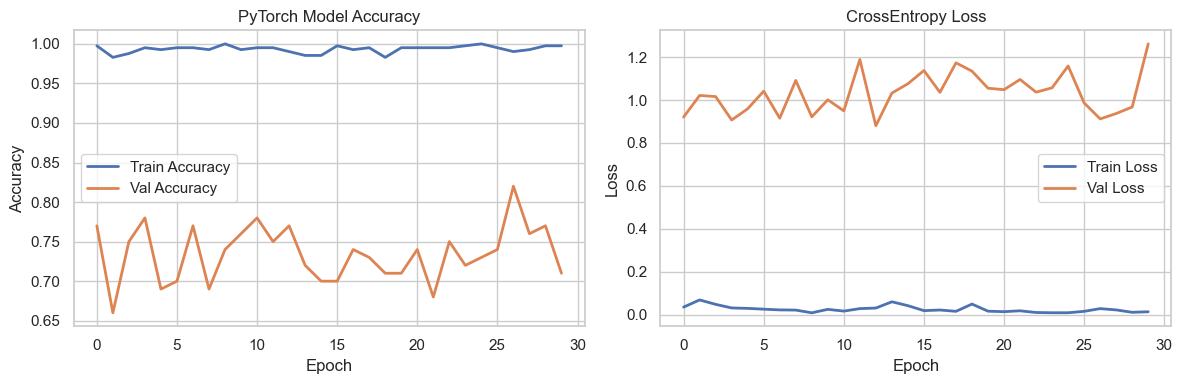

In [19]:
# Hyperparameters
epochs = 30
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Tracking history for plotting
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Starting training...")

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train() # Set model to training mode
    running_loss, running_corrects, total_samples = 0.0, 0, 0

    for images, tabular, labels in best_train_loader:
        # Move data to GPU
        images, tabular, labels = images.to(device), tabular.to(device), labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images, tabular)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels.data).item()
        total_samples += images.size(0)

    epoch_train_loss = running_loss / total_samples
    epoch_train_acc = running_corrects / total_samples

    # --- VALIDATION PHASE ---
    model.eval() # Set model to evaluation mode (disables dropout)
    val_loss, val_corrects, val_samples = 0.0, 0, 0

    with torch.no_grad(): # Disable gradient calculation for speed
        for images, tabular, labels in best_val_loader:
            images, tabular, labels = images.to(device), tabular.to(device), labels.to(device)

            outputs = model(images, tabular)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * images.size(0)
            val_corrects += torch.sum(preds == labels.data).item()
            val_samples += images.size(0)

    epoch_val_loss = val_loss / val_samples
    epoch_val_acc = val_corrects / val_samples

    # Save metrics
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")

# Plotting the Results
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy', lw=2)
plt.plot(history['val_acc'], label='Val Accuracy', lw=2)
plt.title('PyTorch Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', lw=2)
plt.plot(history['val_loss'], label='Val Loss', lw=2)
plt.title('CrossEntropy Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()